In [ ]:
import os
import glob
import numpy as np
import pandas as pd
!pip install lightkurve
import lightkurve as lk
from scipy.interpolate import interp1d
import concurrent.futures
from tqdm import tqdm
import warnings

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- CONFIGURATION ---
KOI_FILE = "/content/drive/MyDrive/project3/q1_q8_koi_2025.02.03_04.12.15.csv"  # Your catalog file
OUTPUT_DIR = "pipeline_output_final"
BATCH_SIZE = 20
WORKERS = 4  # Adjust based on your CPU cores
TIMEOUT_SECONDS = 60   # Max time to wait for a single star before skipping

# Image Shapes for ML Team
CNN_GLOBAL_LEN = 2001
CNN_LOCAL_LEN = 201

# Flags
EXPORT_UNFOLDED = True  # Set True to save raw .csvs for Bayesian Signal Detection
INJECT_SYNTHETIC = True # Set True if you have 'batman' installed and want to inject planets

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    if EXPORT_UNFOLDED:
        os.makedirs(f"{OUTPUT_DIR}/bayesian_unfolded")

In [ ]:
# --- 1. SYNTHETIC INJECTION (OPTIONAL) ---
def inject_transit(lc, period, t0, planet_radius, star_radius):
    """
    Injects a synthetic transit using the `batman` package.
    [cite_start]References: [cite: 13, 33, 90]
    """
    try:
        import batman
    except ImportError:
        print("Batman package not installed. Skipping injection.")
        return lc

    time = lc.time.value

    # Define Batman params
    params = batman.TransitParams()
    params.t0 = t0
    params.per = period
    params.rp = planet_radius / star_radius
    params.a = 15.0 # Semi-major axis (approximation)
    params.inc = 90.0
    params.ecc = 0.0
    params.w = 90.0
    params.u = [0.1, 0.3] # Limb darkening
    params.limb_dark = "quadratic"

    m = batman.TransitModel(params, time)
    flux = m.light_curve(params)

    # Inject into existing flux
    lc.flux *= flux
    return lc

In [ ]:
# --- UPDATED DATA PROCESSING WITH FLUX ERRORS ---
def build_views(lc, period, t0, duration):
    """
    Generates Global and Local views for both FLUX and FLUX_ERR.
    """
    try:
        # 1. Normalize Flux AND Error
        # We normalize by the median flux.
        # For error: If flux is divided by M, error must also be divided by M.
        global_median = np.nanmedian(lc.flux.value)

        # Normalize in place (lightkurve objects are immutable-ish, so we extract values)
        # Note: We re-normalize locally in the fold, but this gets us to relative units.
        norm_flux = (lc.flux.value - global_median) / global_median
        norm_err = lc.flux_err.value / global_median

        # 2. Fold
        folded = lc.fold(period=period, t0=t0)

        # Extract Arrays
        phase = folded.phase.value
        flux = folded.flux.value
        # We need to map the normalized error to the folded indices
        # Since lc.fold() preserves order relative to phase but shuffles time,
        # we rely on lightkurve's internal handling or just fold the error too if supported.
        # Safest way with Lightkurve:
        flux_err = folded.flux_err.value

        # Re-Normalize Folded Data (Local Median = 0)
        local_median = np.nanmedian(flux)
        flux = (flux - local_median) / local_median
        flux_err = flux_err / local_median # Scale error by same factor

        # Sort
        sort_idx = np.argsort(phase)
        phase = phase[sort_idx]
        flux = flux[sort_idx]
        flux_err = flux_err[sort_idx]

        # 3. Interpolate (Flux AND Error)
        # We interpolate error linearly. It's an approximation but necessary for fixed-size CNN inputs.
        f_interp = interp1d(phase, flux, kind='linear', fill_value="extrapolate")
        e_interp = interp1d(phase, flux_err, kind='linear', fill_value="extrapolate")

        # --- GLOBAL VIEW ---
        x_global = np.linspace(-0.5, 0.5, CNN_GLOBAL_LEN)
        view_global = f_interp(x_global)
        error_global = e_interp(x_global)

        # --- LOCAL VIEW ---
        duration_days = duration / 24.0
        duration_phase = duration_days / period
        zoom_width = duration_phase * 2.5

        x_local = np.linspace(-zoom_width, zoom_width, CNN_LOCAL_LEN)
        view_local = f_interp(x_local)
        error_local = e_interp(x_local)

        # --- TIME AXIS ---
        time_local_hours = x_local * period * 24.0

        return view_global, view_local, error_global, error_local, time_local_hours

    except Exception as e:
        return None, None, None, None, None

def process_star(task):
    row = task['row']
    label = task['label']
    kic = int(row['kepid'])

    period = float(row['koi_period'])
    t0 = float(row['koi_time0bk'])
    duration = float(row['koi_duration'])

    try:
        # Download & Stitch
        search = lk.search_lightcurve(f"KIC {kic}", author="Kepler", cadence="long")
        if len(search) == 0: return None
        lc_coll = search.download_all()
        if lc_coll is None: return None
         # "Stitch together quarters" to ensure full coverage and better SNR
        lc_raw = lc_coll.stitch()

        # Detrend
        # Flatten removes low-frequency stellar variability (rotation, spots)
        # window_length should be larger than transit duration
        lc_clean = lc_raw.remove_nans().flatten(window_length=401).remove_outliers(sigma=5)

        if INJECT_SYNTHETIC and label == 0:
            # We inject a signal using the metadata from the 'row'
            # (treating the false positive metadata as the "fake planet" properties)
            # OR you can randomize these parameters if you prefer random planets.
            lc_clean = inject_transit(
                lc_clean,
                period=period,
                t0=t0,
                planet_radius=float(row.get('koi_prad', 2.0)),
                star_radius=float(row.get('koi_srad', 1.0))
            )
            # IMPORTANT: Change label to 1 because it now HAS a planet
            label = 1

        # Save Unfolded for Bayesian (Now explicitly with Error)
        if EXPORT_UNFOLDED:
            pd.DataFrame({
                'time': lc_clean.time.value,
                'flux': lc_clean.flux.value,
                'flux_err': lc_clean.flux_err.value
            }).to_csv(f"{OUTPUT_DIR}/bayesian_unfolded/kic_{kic}_unfolded.csv", index=False)

        # Generate ML Views (Now includes Error views)
        v_glob, v_loc, e_glob, e_loc, t_loc = build_views(lc_clean, period, t0, duration)

        if v_glob is None: return None

        return {
            'flux_global': v_glob.astype(np.float32),
            'flux_local': v_loc.astype(np.float32),
            'error_global': e_glob.astype(np.float32),
            'error_local': e_loc.astype(np.float32),
            'time_local': t_loc.astype(np.float32),
            'kic': kic,
            'label': label,
            'period': period,
            't0': t0,
            'duration': duration,
            'transit_depth': float(row.get('koi_depth', 0)),
            'snr': float(row.get('koi_model_snr', 0))
        }

    except Exception as e:
        return None

In [ ]:
def get_resume_state():
    """Finds completed stars by checking if BOTH metadata AND npz exist."""
    processed_kics = set()
    next_idx = 0

    # Look for matching pairs of .npz and _meta.csv
    meta_files = glob.glob(f"{OUTPUT_DIR}/batch_*_meta.csv")

    print(f"Scanning {len(meta_files)} batches for existing progress...")

    valid_indices = []
    for f in meta_files:
        try:
            # Extract Batch ID
            batch_id = int(os.path.basename(f).split('_')[1])
            npz_path = f"{OUTPUT_DIR}/batch_{batch_id}.npz"

            # STRICT CHECK: Must have both files to count as "done"
            if os.path.exists(npz_path):
                df = pd.read_csv(f, usecols=['kic'])
                processed_kics.update(df['kic'].astype(int).tolist())
                valid_indices.append(batch_id)
        except:
            continue

    if valid_indices:
        next_idx = max(valid_indices) + 1

    return processed_kics, next_idx

def save_batch(data, idx):
    if not data: return

    try:
        # 1. Save Arrays (.npz)
        arrays = {k: np.array([d[k] for d in data]) for k in ['flux_global', 'flux_local', 'error_global', 'error_local', 'time_local']}
        np.savez_compressed(f"{OUTPUT_DIR}/batch_{idx}.npz", **arrays)

        # 2. Save Metadata (.csv)
        meta_data = [{k: v for k, v in d.items() if k not in arrays} for d in data]
        pd.DataFrame(meta_data).to_csv(f"{OUTPUT_DIR}/batch_{idx}_meta.csv", index=False)

        print(f"  [SAVED] Batch {idx} ({len(data)} stars) -> {OUTPUT_DIR}")
    except Exception as e:
        print(f"  [ERROR] Failed to save batch {idx}: {e}")

def merge_metadata():
    """Safely merges only the CSV files into a master index."""
    print("\n--- Finalizing Metadata ---")
    meta_files = sorted(glob.glob(f"{OUTPUT_DIR}/batch_*_meta.csv"))

    if not meta_files:
        print("No batches found to merge.")
        return

    all_dfs = []
    for f in tqdm(meta_files, desc="Merging"):
        try:
            df = pd.read_csv(f)
            # Add pointer to the NPZ file
            df['filename'] = os.path.basename(f).replace("_meta.csv", ".npz")
            df['index_in_batch'] = np.arange(len(df))
            all_dfs.append(df)
        except:
            print(f"Skipping corrupt file: {f}")

    if all_dfs:
        final_df = pd.concat(all_dfs, ignore_index=True)
        final_df.to_csv(f"{OUTPUT_DIR}/final_metadata.csv", index=False)
        print(f"SUCCESS: Master Index saved to {OUTPUT_DIR}/final_metadata.csv")
        print(f"Total Processed Stars: {len(final_df)}")
    else:
        print("Merge failed: No valid data found.")

def run_pipeline():
    print("Loading Catalog...")
    df = pd.read_csv(KOI_FILE, comment='#').dropna(subset=['kepid', 'koi_period'])

    # Balanced Sampling
    pos = df[df['koi_disposition'] == 'CONFIRMED']
    neg = df[df['koi_disposition'] == 'FALSE POSITIVE']

    n_target = 500
    # Seeded sampling for consistency
    tasks = []
    for _, r in pos.sample(n=min(len(pos), n_target), random_state=42).iterrows():
        tasks.append({'row': r, 'label': 1})
    for _, r in neg.sample(n=min(len(neg), n_target), random_state=42).iterrows():
        tasks.append({'row': r, 'label': 0})

    # Check Resume Status
    done_kics, batch_idx = get_resume_state()
    tasks_to_run = [t for t in tasks if int(t['row']['kepid']) not in done_kics]

    print(f"Total Tasks: {len(tasks)} | Already Done: {len(done_kics)} | Remaining: {len(tasks_to_run)}")

    if not tasks_to_run:
        print("All stars processed.")
        return

    # Execution with Timeout
    current_batch = []
    print(f"Starting processing with {WORKERS} workers...")

    with concurrent.futures.ThreadPoolExecutor(max_workers=WORKERS) as executor:
        future_map = {executor.submit(process_star, t): t for t in tasks_to_run}

        for future in tqdm(concurrent.futures.as_completed(future_map), total=len(tasks_to_run)):
            try:
                # Timeout prevents hanging on bad downloads
                res = future.result(timeout=TIMEOUT_SECONDS)
                if res:
                    current_batch.append(res)
            except:
                pass # Fail silently on individual stars to keep pipeline moving

            if len(current_batch) >= BATCH_SIZE:
                save_batch(current_batch, batch_idx)
                current_batch = []
                batch_idx += 1

    if current_batch:
        save_batch(current_batch, batch_idx)

def force_merge():
    print(f"Scanning '{OUTPUT_DIR}' for existing batches...")
    
    # 1. Find all batch metadata files
    meta_files = sorted(glob.glob(f"{OUTPUT_DIR}/batch_*_meta.csv"))
    
    if not meta_files:
        print("❌ No batch files found. Nothing to merge.")
        return

    print(f"Found {len(meta_files)} batches. Merging now...")

    # 2. Read and Combine
    all_meta = []
    total_stars = 0
    
    for f in meta_files:
        try:
            df = pd.read_csv(f)
            
            # CRITICAL: Link this row to its specific .npz file
            # e.g., "batch_0_meta.csv" -> "batch_0.npz"
            batch_filename = os.path.basename(f).replace("_meta.csv", ".npz")
            df['filename'] = batch_filename
            
            # Create a local index (0, 1, 2...) so the loader knows which array to grab
            df['index_in_batch'] = np.arange(len(df))
            
            all_meta.append(df)
            total_stars += len(df)
            print(f"  - Loaded {os.path.basename(f)} ({len(df)} stars)")
            
        except Exception as e:
            print(f"  ⚠️ Skipping corrupt file {f}: {e}")

    # 3. Save Final Index
    if all_meta:
        final_df = pd.concat(all_meta, ignore_index=True)
        final_df.to_csv(f"{OUTPUT_DIR}/final_metadata.csv", index=False)
        
        print("-" * 40)
        print(f"✅ MERGE COMPLETE")
        print(f"Total Stars Secured: {len(final_df)}")
        print(f"  - Planets:         {len(final_df[final_df['label'] == 1])}")
        print(f"  - False Positives: {len(final_df[final_df['label'] == 0])}")
        print(f"Master Index saved to: {f"{OUTPUT_DIR}/final_metadata.csv"}")
        print("-" * 40)
        print("You can now proceed to training your models.")
    else:
        print("Merge failed: valid files found, but dataframes were empty.")

In [ ]:
#print(f"DONE. Master Index: {OUTPUT_DIR}/final_metadata.csv")
#print(f"Total Stars: {len(final_df)}")
#print(f"Total Stars: {len(final_df)}")
#print(f"  - Confirmed Planets: {len(final_df[final_df['label'] == 1])}")
#print(f"  - False Positives:   {len(final_df[final_df['label'] == 0])}")

In [ ]:
if __name__ == "__main__":
    run_pipeline()
    #merge_metadata()
    #force_merge()

Loading Catalog...
Scanning 6 batches for existing progress...
Total Tasks: 1000 | Already Done: 113 | Remaining: 868
Starting processing with 4 workers...


 55%|█████▍    | 475/868 [21:30<18:16,  2.79s/it]

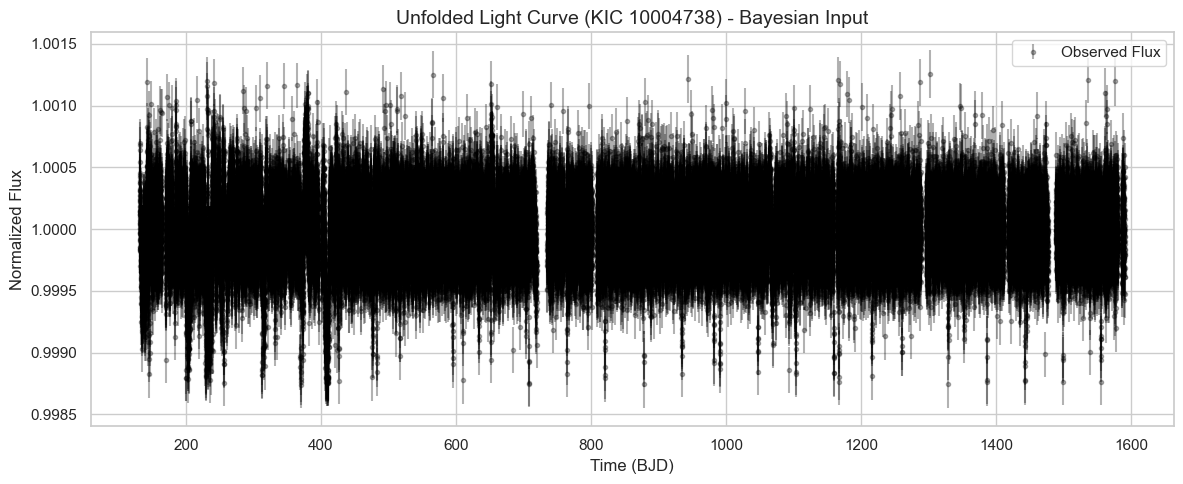

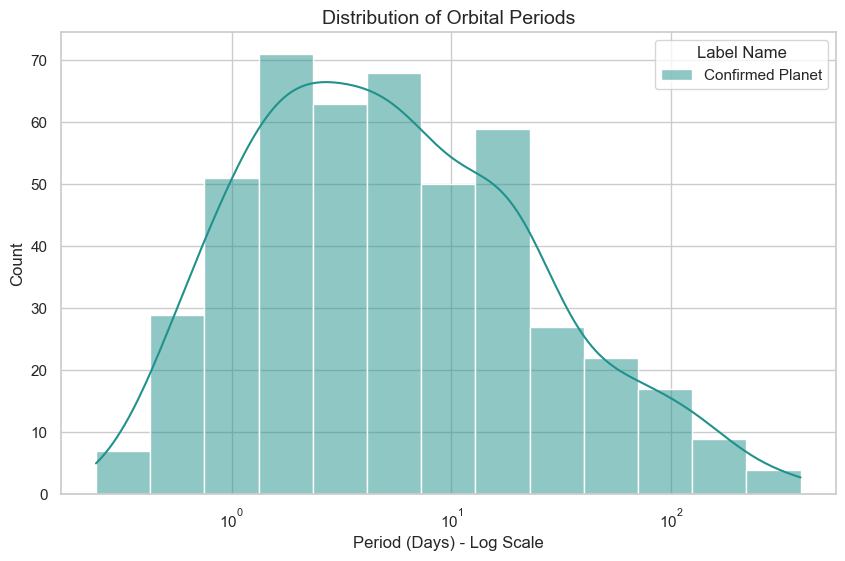

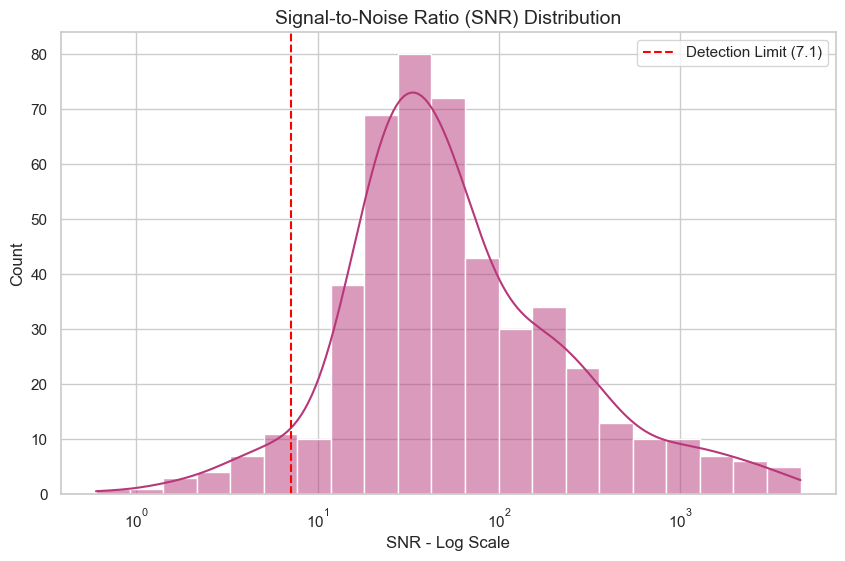

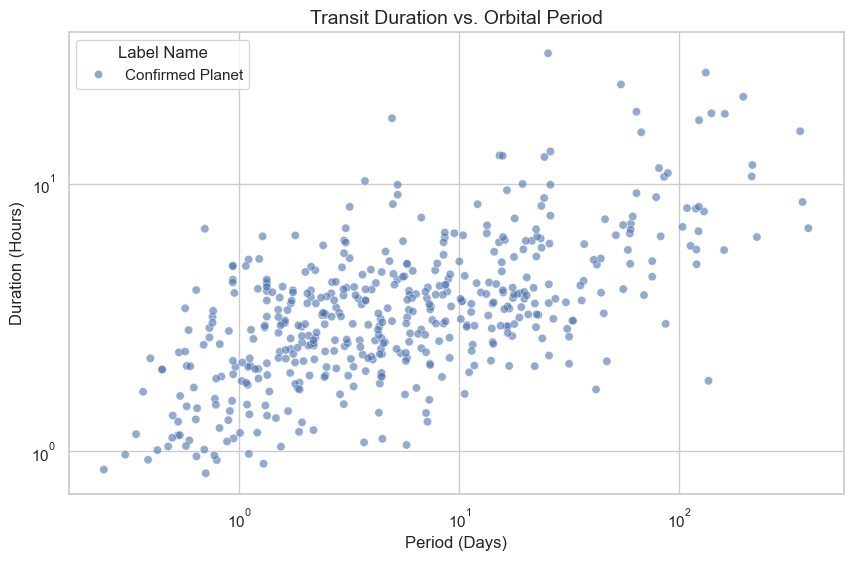

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
DATA_DIR = "pipeline_output_final"
METADATA_FILE = f"{DATA_DIR}/final_metadata.csv"

# Set style
sns.set_theme(style="whitegrid")

def plot_bayesian_example():
    """Plots one random unfolded light curve for the Bayesian team."""
    files = glob.glob(f"{DATA_DIR}/bayesian_unfolded/*.csv")
    if not files:
        print("No unfolded CSVs found.")
        return

    # Pick the first one (or random)
    filename = files[0]
    kic = os.path.basename(filename).split('_')[1]

    df = pd.read_csv(filename)

    plt.figure(figsize=(12, 5))
    # Plot data with error bars (subsampled for speed if needed)
    plt.errorbar(df['time'], df['flux'], yerr=df['flux_err'],
                 fmt='.', color='black', alpha=0.3, label='Observed Flux')

    plt.title(f"Unfolded Light Curve (KIC {kic}) - Bayesian Input", fontsize=14)
    plt.xlabel("Time (BJD)", fontsize=12)
    plt.ylabel("Normalized Flux", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig("bayesian_example.png")
    plt.show()

def plot_dataset_statistics():
    """Plots relationships in the metadata."""
    if not os.path.exists(METADATA_FILE):
        print("Metadata file not found.")
        return

    df = pd.read_csv(METADATA_FILE)

    # Map labels for better legend
    df['Label Name'] = df['label'].map({1: 'Confirmed Planet', 0: 'False Positive'})

    # 1. Period Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='period', hue='Label Name', log_scale=True, kde=True, palette='viridis')
    plt.title("Distribution of Orbital Periods", fontsize=14)
    plt.xlabel("Period (Days) - Log Scale", fontsize=12)
    plt.savefig("dist_period.png")
    plt.show()

    # 2. SNR Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='snr', hue='Label Name', log_scale=True, kde=True, palette='magma')
    plt.axvline(7.1, color='red', linestyle='--', label='Detection Limit (7.1)')
    plt.title("Signal-to-Noise Ratio (SNR) Distribution", fontsize=14)
    plt.xlabel("SNR - Log Scale", fontsize=12)
    plt.legend()
    plt.savefig("dist_snr.png")
    plt.show()

    # 3. Period vs Duration (Physics Check)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='period', y='duration', hue='Label Name', alpha=0.6)
    plt.xscale('log')
    plt.yscale('log')
    plt.title("Transit Duration vs. Orbital Period", fontsize=14)
    plt.xlabel("Period (Days)", fontsize=12)
    plt.ylabel("Duration (Hours)", fontsize=12)
    plt.savefig("scatter_period_duration.png")
    plt.show()

if __name__ == "__main__":
    plot_bayesian_example()
    plot_dataset_statistics()